In [1]:
import pandas as pd

data = {
    "shipment_id": ["S001", "S002", "S003", "S004", "S005"],
    "zone": ["A", "B", "A", "C", "B"],
    "delivery_hours": [2, 5, 3, 7, 4],
    "on_time": ["Yes", "No", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)

print(df)

C:\Users\koush\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


  shipment_id zone  delivery_hours on_time
0        S001    A               2     Yes
1        S002    B               5      No
2        S003    A               3     Yes
3        S004    C               7      No
4        S005    B               4     Yes


In [2]:
##calculate the on-time delivery rate:

total = len(df)

on_time_count = (df["on_time"] == "Yes").sum()

rate = (on_time_count / total) * 100

print("On-time delivery rate:", rate, "%")

On-time delivery rate: 60.0 %


In [3]:
##calculate average delivery time:

average = df["delivery_hours"].mean()

print("Average delivery time:", average, "hours")

Average delivery time: 4.2 hours


In [4]:
# Calculate the delay rate

delay_count = (df["on_time"] == "No").sum()

delay_rate = (delay_count / total) * 100

print("Delay rate:", delay_rate, "%")

Delay rate: 40.0 %


In [5]:
df.head()

,shipment_id,zone,delivery_hours,on_time
0,S001,A,2,Yes
1,S002,B,5,No
2,S003,A,3,Yes
3,S004,C,7,No
4,S005,B,4,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   shipment_id     5 non-null      str  
 1   zone            5 non-null      str  
 2   delivery_hours  5 non-null      int64
 3   on_time         5 non-null      str  
dtypes: int64(1), str(3)
memory usage: 330.0 bytes


In [7]:
df.describe()

,delivery_hours
count,5.000000
mean,4.200000
std,1.923538
min,2.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [8]:
# Check the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5
Number of columns: 4


In [9]:
# Check column names and data types

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   shipment_id     5 non-null      str  
 1   zone            5 non-null      str  
 2   delivery_hours  5 non-null      int64
 3   on_time         5 non-null      str  
dtypes: int64(1), str(3)
memory usage: 330.0 bytes
None


In [10]:
# Check for missing values

print(df.isnull().sum())

shipment_id       0
zone              0
delivery_hours    0
on_time           0
dtype: int64


In [11]:
# Count the number of shipments in each zone

zone_count = df["zone"].value_counts()

print(zone_count)

zone
A    2
B    2
C    1
Name: count, dtype: int64


In [12]:
# Calculate average delivery time by zone

average_delivery_by_zone = df.groupby("zone")["delivery_hours"].mean()

print(average_delivery_by_zone)

zone
A    2.5
B    4.5
C    7.0
Name: delivery_hours, dtype: float64


In [13]:
# Count on-time and delayed shipments by zone

zone_performance = pd.crosstab(df["zone"], df["on_time"])

print(zone_performance)

on_time  No  Yes
zone            
A         0    2
B         1    1
C         1    0


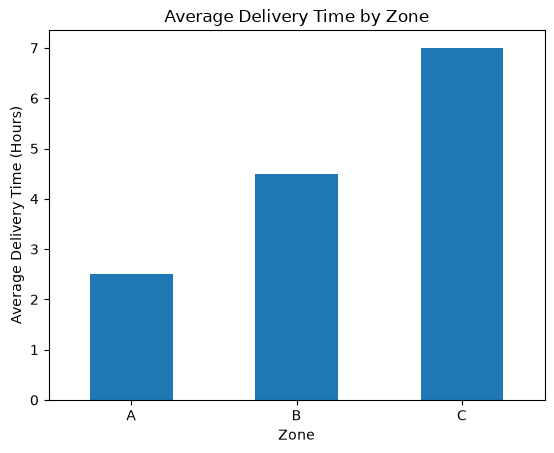

In [14]:
import matplotlib.pyplot as plt

# Average delivery time by zone
average_delivery_by_zone = df.groupby("zone")["delivery_hours"].mean()

# Create bar chart
average_delivery_by_zone.plot(kind="bar")

plt.title("Average Delivery Time by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Delivery Time (Hours)")
plt.xticks(rotation=0)

plt.show()

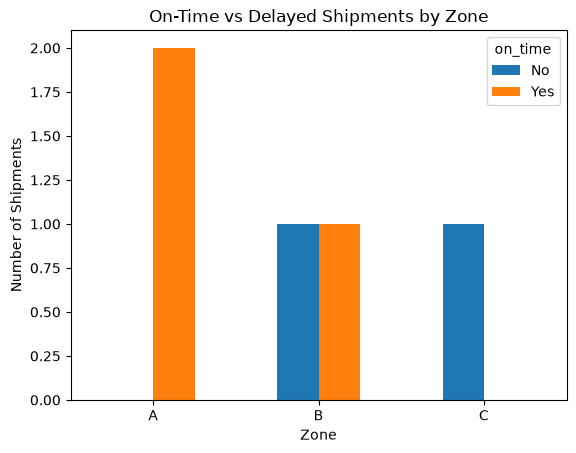

In [15]:
# On-time vs delayed shipments by zone

zone_performance = pd.crosstab(df["zone"], df["on_time"])

zone_performance.plot(kind="bar")

plt.title("On-Time vs Delayed Shipments by Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)

plt.show()

In [16]:
# Calculate on-time delivery rate by zone

zone_on_time_rate = df.groupby("zone")["on_time"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(zone_on_time_rate)

zone
A    100.0
B     50.0
C      0.0
Name: on_time, dtype: float64


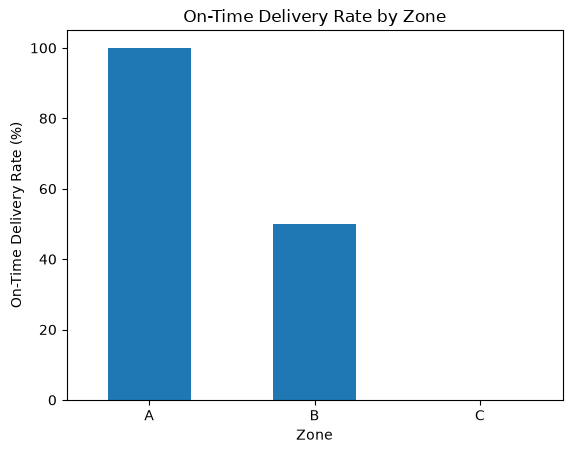

In [17]:
# Plot on-time delivery rate by zone

zone_on_time_rate.plot(kind="bar")

plt.title("On-Time Delivery Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("On-Time Delivery Rate (%)")
plt.xticks(rotation=0)

plt.show()

## Key Findings

- Overall on-time delivery rate is 60%.
- Overall delay rate is 40%.
- Average delivery time is 4.2 hours.
- Zone A has the highest on-time delivery rate at 100%.
- Zone C has the lowest on-time delivery rate at 0%.
- Zone C has the highest average delivery time at 7 hours.
- Zone B has an on-time delivery rate of 50%.

Note: These findings are based on a small sample dataset of 5 shipments and should not be treated as final business conclusions.